# Damages USA - Litpop data from Denisa

This notebook calculates damage using the experiments conducted, the emanuel_2011 damage function, and the Litpop file reprocessed by Denisa, and then applies the correction ratios provided by Ruben.

Identified issues: We are unsure of the reprocessing steps used to generate the reprocessed Litpop files, and the data is available only for the U.S. and China. 

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import pandas as pd
from pathlib import Path
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.dataset as ds
import pyarrow.compute as pc
import pyarrow.csv as pv
import pyarrow as pa
import numpy as np
import polars as pl
import geopandas as gpd
import reverse_geocode
from src.damages.damage_functions import emanuel_2011
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import tarfile
import io
import tomllib
import os

import geopandas as gpd
from shapely.geometry import Point
from shapely.prepared import prep
import matplotlib.pyplot as plt
import contextily as ctx
import matplotlib.colors as mcolors

import gc

from scipy.spatial import cKDTree
from pyproj import Transformer
import psutil

from multiprocessing import Process

## Données litpop de Denisa

In [3]:
litpop_dir = Path("../data/input/wealth_densities/litpop/5 minutes")
litpop = pd.concat([pd.read_hdf(fpath) for fpath in litpop_dir.glob("*.hdf5")], axis=0,ignore_index=True)
litpop = gpd.GeoDataFrame(litpop, geometry="geometry", crs="EPSG:4326")

In [4]:
litpop.shape

(297776, 6)

Ajout du pays

In [5]:
# Pays du monde
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

# Jointure spatiale
litpop_with_country = gpd.sjoin(
    litpop,
    world[["NAME", "geometry"]],
    how="left",
    predicate="within"
)

litpop_with_country.rename(columns={"NAME": "country"}, inplace=True)

# Comptage par pays
litpop_with_country["country"].value_counts()

country
United States of America    159108
China                       136004
Russia                         158
Canada                         145
Kazakhstan                      96
Mongolia                        94
India                           85
Nepal                           76
Myanmar                         56
North Korea                     52
Pakistan                        46
Vietnam                         45
Mexico                          20
Afghanistan                     17
Tajikistan                      14
Kyrgyzstan                      11
Bhutan                           7
Laos                             1
Name: count, dtype: int64

In [6]:
litpop_with_country.groupby("country")["value"].sum().sort_values(ascending=False)
# que usa chine et quelques points chez leurs voisins !

country
United States of America    7.631615e+13
China                       3.892458e+13
Canada                      3.344525e+10
Vietnam                     1.469970e+09
Mexico                      1.398046e+09
Kazakhstan                  7.496313e+08
North Korea                 2.363025e+08
Russia                      1.648173e+08
Myanmar                     1.013447e+08
Nepal                       9.097176e+06
India                       7.820104e+06
Mongolia                    2.235111e+06
Pakistan                    1.998279e+06
Bhutan                      8.002225e+05
Kyrgyzstan                  5.563185e+05
Afghanistan                 4.138003e+05
Laos                        2.677707e+05
Tajikistan                  1.772119e+05
Name: value, dtype: float64

In [7]:
model = "ACCESS-CM2"
experiment = "ssp585"

output_dir = Path(f"../data/output/damages/national/{model}/{experiment}")
tracks_dir = Path(f"../data/output/catherina/intensified_tracks/{model}/{experiment}")

In [8]:
tracks_ds = ds.dataset(tracks_dir, partitioning="hive")

Jointure des tracks avec les données litpop 

In [9]:
# On crée en output un fichier par année, donc avec tous les seeds mélangés : il faudra faire un groupby

transformer = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:3857",
    always_xy=True,
)

# ------------------------------------------------------------------
# LitPop
# ------------------------------------------------------------------

lit_x, lit_y = transformer.transform(
    litpop_with_country.geometry.x.values,
    litpop_with_country.geometry.y.values,
)

lit_coords = np.column_stack(
    (lit_x, lit_y)
).astype(np.float32)

tree = cKDTree(lit_coords)

lit_val = litpop_with_country["value"].to_numpy(
    dtype=np.float32
)

lit_country = (
    litpop_with_country["country"]
    .fillna("Unknown")
    .astype(str)
    .to_numpy()
)


def mem():
    return psutil.Process(
        os.getpid()
    ).memory_info().rss / 1e9


def process_year(
    year,
    tracks_ds,
    tree,
    lit_val,
    lit_country,
):

    print(f"\n===== YEAR {year} =====")
    print(f"[START RAM] {mem():.2f} GB")

    table = tracks_ds.to_table(
        filter=(ds.field("year") == year),
        columns=[
            "seed",          
            "month",
            "lat_left",
            "lon_left",
            "final_wind_speed",
        ],
    )

    n = table.num_rows

    print(f"[ROWS] {n:,}")

    if n == 0:
        return

    seed = table.column("seed").to_numpy()

    lat = table.column("lat_left").to_numpy()
    lon = table.column("lon_left").to_numpy()
    wind = table.column("final_wind_speed").to_numpy()
    month = table.column("month").to_numpy()

    x, y = transformer.transform(lon, lat)

    coords = np.column_stack(
        (x, y)
    ).astype(
        np.float32,
        copy=False,
    )

    _, idx = tree.query(
        coords,
        k=1,
        workers=-1,
    )

    value = lit_val[idx]
    country = lit_country[idx]

    rel = emanuel_2011(wind)
    loss = rel * value

    output_file = output_dir / f"year={year}.parquet"

    output_file.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    pq.write_table(
        pa.table(
            {
                "year": np.full(
                    n,
                    year,
                    dtype=np.int32,
                ),
                "seed": seed, 
                "month": month,
                "lat_left": lat,
                "lon_left": lon,
                "final_wind_speed": wind,
                "country": country,
                "value": value,
                "relative_losses": rel,
                "losses": loss,
            }
        ),
        output_file,
        compression="zstd",
    )

    print(f"[END RAM] {mem():.2f} GB")

    del (
        table,
        seed,
        lat,
        lon,
        wind,
        month,
        coords,
        idx,
        value,
        country,
        rel,
        loss,
    )

    gc.collect()


def run_all_years(
    years,
    tracks_ds,
    tree,
    lit_val,
    lit_country,
):

    for year in years:

        p = Process(
            target=process_year,
            args=(
                year,
                tracks_ds,
                tree,
                lit_val,
                lit_country,
            ),
        )

        p.start()
        p.join()


run_all_years(
    range(2025, 2100),
    tracks_ds,
    tree,
    lit_val,
    lit_country,
)


===== YEAR 2025 =====
[START RAM] 0.99 GB
[ROWS] 396,471


/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(


[END RAM] 1.42 GB

===== YEAR 2026 =====
[START RAM] 0.99 GB
[ROWS] 697,477


/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(


[END RAM] 1.62 GB

===== YEAR 2027 =====
[START RAM] 0.99 GB
[ROWS] 689,571


...

[END RAM] 1.66 GB

===== YEAR 2098 =====
[START RAM] 0.99 GB
[ROWS] 871,846


/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(


[END RAM] 1.65 GB

===== YEAR 2099 =====
[START RAM] 0.99 GB
[ROWS] 873,982


/home/tiphanie/projets_python/catherina/src/damages/damage_functions.py:131: UserWarning: The default value for 'v_half' has not been changed. The current value was calibrated on US tropical cyclones.
  warnings.warn(


[END RAM] 1.65 GB


In [ ]:
# Aggregate
all_losses = pl.read_parquet(output_dir / "*.parquet").to_pandas()
all_losses_grouped = all_losses.groupby(["year", "country", "seed"]).agg({"losses": "sum"})
n_seeds = all_losses_grouped.seed.nunique()

all_losses_grouped.to_parquet(output_dir / "all_losses_by_year.parquet")

In [12]:
all_losses_grouped = all_losses_grouped.reset_index()
USA_annual_losses_mean = all_losses_grouped[
    all_losses_grouped.country == "United States of America"
].groupby(["year", "country"])["losses"].mean().values

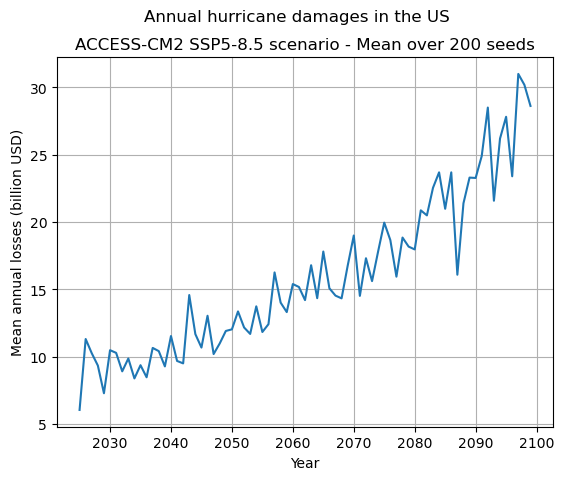

In [31]:
fig, ax = plt.subplots()
ax.plot(range(2025, 2100), USA_annual_losses_mean/1e9)
plt.xlabel("Year")
plt.ylabel("Mean annual losses (billion USD)")
plt.suptitle("Annual hurricane damages in the US")
plt.title(f"ACCESS-CM2 SSP5-8.5 scenario - Mean over {n_seeds} seeds")
plt.grid()
plt.show()

## Add correction ratios

These ratios were calculated to adjust the estimated damages based on past damages.

In [14]:
ratio = pd.read_csv("../data/input/wealth_densities/ratio_correction/country_rmsf_corr.csv", sep=";")
ratio_US = float(ratio[ratio["iso3"] == "USA"]["correction"].values[0].replace(",", "."))

In [15]:
ratio_US

0.685299803

In [18]:
losses_to_plot_with_ratio = ratio_US * all_losses[
    all_losses.country == "United States of America"
].groupby(
    ["year", "country", "seed"]
).agg({"losses": "sum"})

In [22]:
losses_per_year_with_ratio_metrics = (
    losses_to_plot_with_ratio
    .groupby("year")
    .agg(
        mean_losses=("losses", "mean"), 
        p90_losses=("losses", lambda x: np.percentile(x, 90)),
        p95_losses=("losses", lambda x: np.percentile(x, 95))
    ).reset_index()
)

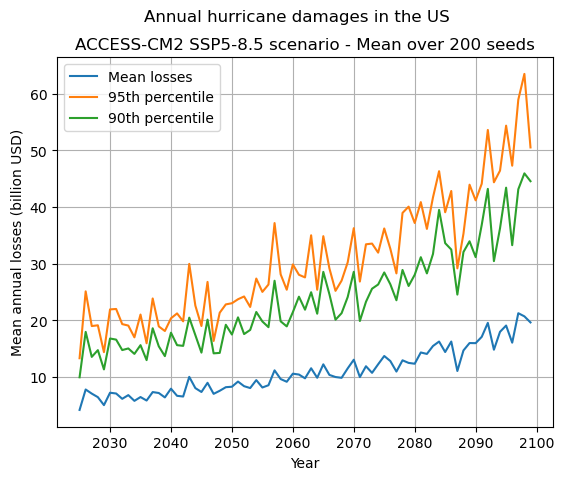

In [29]:
fig, ax = plt.subplots()
ax.plot(losses_per_year_with_ratio_metrics["year"], losses_per_year_with_ratio_metrics["mean_losses"]/1e9)
ax.plot(losses_per_year_with_ratio_metrics["year"], losses_per_year_with_ratio_metrics["p95_losses"]/1e9)
ax.plot(losses_per_year_with_ratio_metrics["year"], losses_per_year_with_ratio_metrics["p90_losses"]/1e9)
plt.xlabel("Year")
plt.ylabel("Mean annual losses (billion USD)")
plt.suptitle("Annual hurricane damages in the US")
plt.title(f"ACCESS-CM2 SSP5-8.5 scenario - Mean over {n_seeds} seeds")
plt.legend(["Mean losses", "95th percentile", "90th percentile"])
plt.grid()
plt.show()